In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from glob import glob
import os
import numpy as np

def get_pftfiles_adsp(prefix, year_range = range(50,100)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB1850CN{nutrient}CTCBC_ad_spinup', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h2.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files

def get_colfiles_adsp(prefix, year_range = range(50,100)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB1850CN{nutrient}CTCBC_ad_spinup', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h1.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files


def get_pftfiles_fnsp(prefix, year_range = range(10)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB1850CNP{nutrient}CTCBC', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h1.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files

def get_colfiles_fnsp(prefix, year_range = range(10)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB1850CNP{nutrient}CTCBC', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h0.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files


def get_pftfiles_trmt(prefix, plot, year_range = range(10)):
    nutrient = 'RD'
    # Path to the folder containing the NetCDF files
    folder_path = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output',             
                            f'{prefix}_US-SPR_ICB20TRCNP{nutrient}CTCBC', 'spruce_treatments',
                            f'plot{plot}_US-SPR_ICB20TRCNP{nutrient}CTCBC', 'run')
    nc_files = sorted(glob(os.path.join(folder_path, "*.h2.*.nc")))[:-1]
    nc_files = [f for f in nc_files if int(f.split('.')[-2].split('-')[0]) in year_range]

    return nc_files

In [2]:
flist = get_pftfiles_adsp('20240316_2', range(25,200))
hr2 = xr.open_mfdataset(flist)

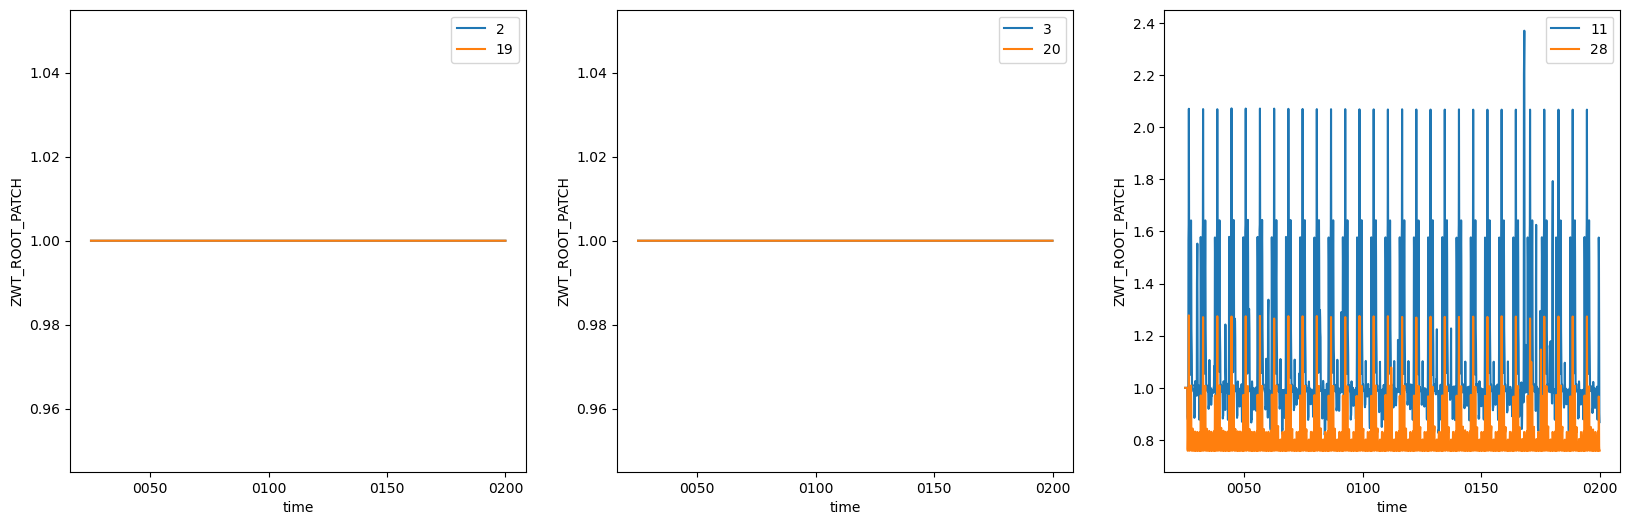

In [3]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]

    frac_fungi = hr2['ZWT_ROOT_PATCH'][:, pft].resample(time='1M').mean()
    #frac_fungi = np.minimum(np.maximum(1 - (frac_fungi - 0.5) / 1.5, 0), 1)
    frac_fungi.plot(label = pft, ax = ax)

    frac_fungi = hr2['ZWT_ROOT_PATCH'][:, pft + 17].resample(time='1M').mean()
    #frac_fungi = np.minimum(np.maximum(1 - (frac_fungi - 0.5) / 1.5, 0), 1)
    frac_fungi.plot(label = pft + 17, ax = ax)

    ax.legend()
    ax.set_ylabel('ZWT_ROOT_PATCH')

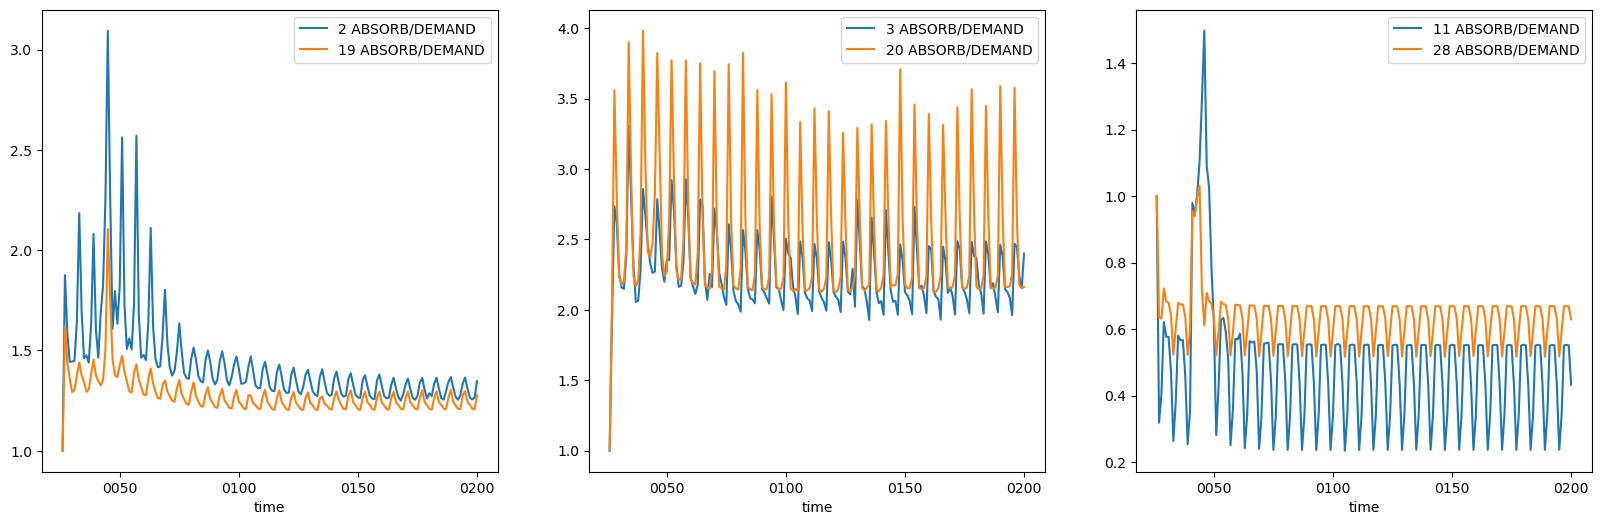

In [18]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    n_absorb = hr2['PLANT_NABSORB'][:, pft].resample(time='1Y').mean()
    n_demand = hr2['PLANT_NDEMAND'][:, pft].resample(time='1Y').mean()
    (n_absorb / n_demand).plot(label = str(pft) + ' ABSORB/DEMAND', ax = ax)

    n_absorb = hr2['PLANT_NABSORB'][:, pft+17].resample(time='1Y').mean()
    n_demand = hr2['PLANT_NDEMAND'][:, pft+17].resample(time='1Y').mean()
    (n_absorb / n_demand).plot(label = str(pft+17) + ' ABSORB/DEMAND', ax = ax)

    ax.legend()

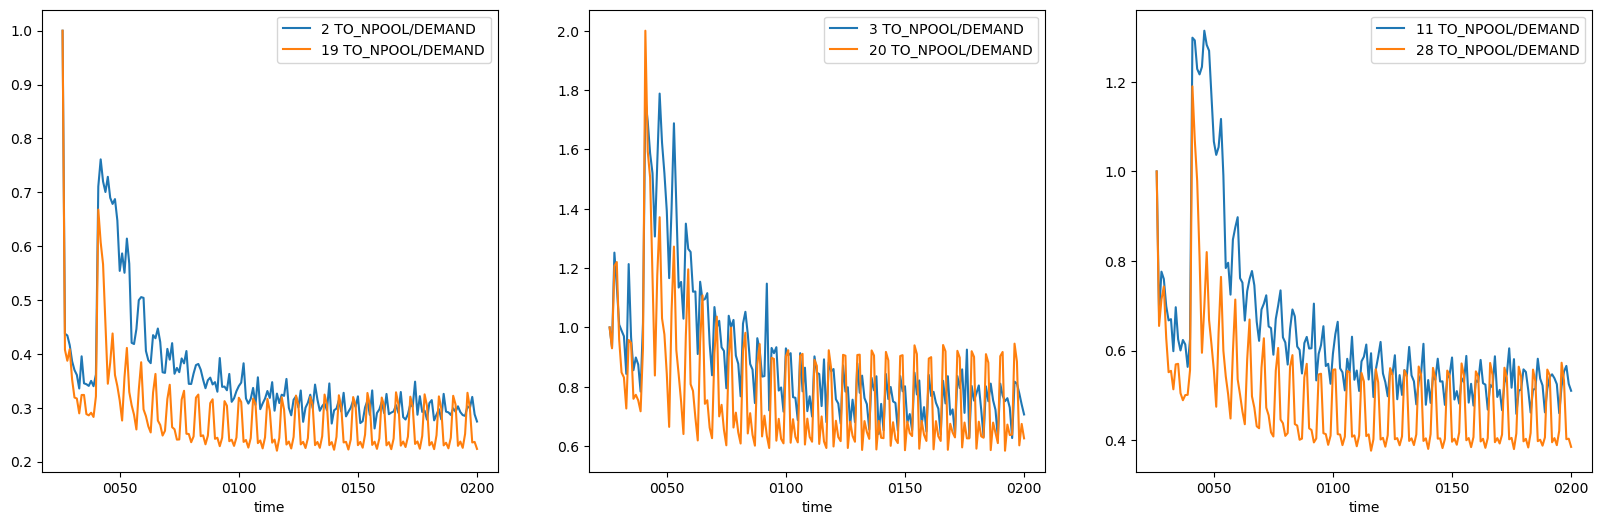

In [4]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    n_absorb = hr2['SMINN_TO_NPOOL'][:, pft].resample(time='1Y').mean()
    n_demand = hr2['PLANT_NDEMAND'][:, pft].resample(time='1Y').mean()
    (n_absorb / n_demand).plot(label = str(pft) + ' TO_NPOOL/DEMAND', ax = ax)

    n_absorb = hr2['SMINN_TO_NPOOL'][:, pft+17].resample(time='1Y').mean()
    n_demand = hr2['PLANT_NDEMAND'][:, pft+17].resample(time='1Y').mean()
    (n_absorb / n_demand).plot(label = str(pft+17) + ' TO_NPOOL/DEMAND', ax = ax)

    ax.legend()

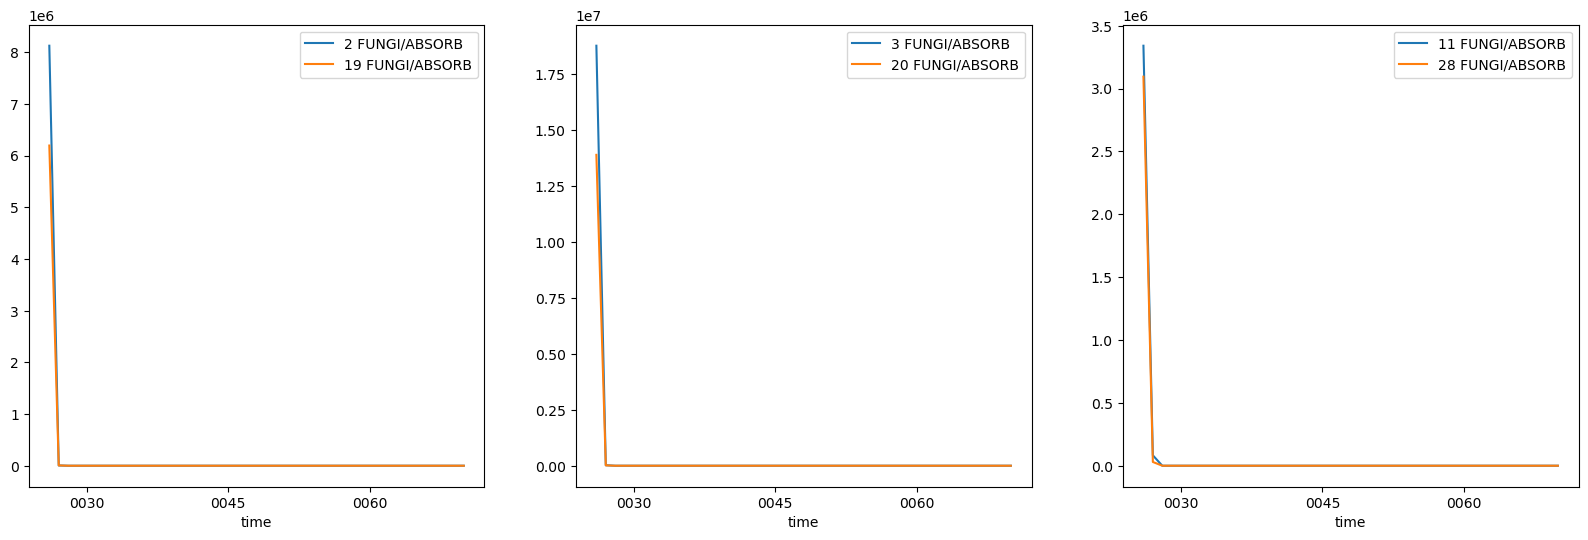

In [6]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    n_absorb = hr2['PLANT_NFUNGI_PATCH'][:, pft].resample(time='1Y').mean()
    n_demand = hr2['PLANT_NABSORB'][:, pft].resample(time='1Y').mean()
    (n_absorb / n_demand).plot(label = str(pft) + ' FUNGI/ABSORB', ax = ax)

    n_absorb = hr2['PLANT_NFUNGI_PATCH'][:, pft+17].resample(time='1Y').mean()
    n_demand = hr2['PLANT_NABSORB'][:, pft+17].resample(time='1Y').mean()
    (n_absorb / n_demand).plot(label = str(pft+17) + ' FUNGI/ABSORB', ax = ax)

    ax.legend()

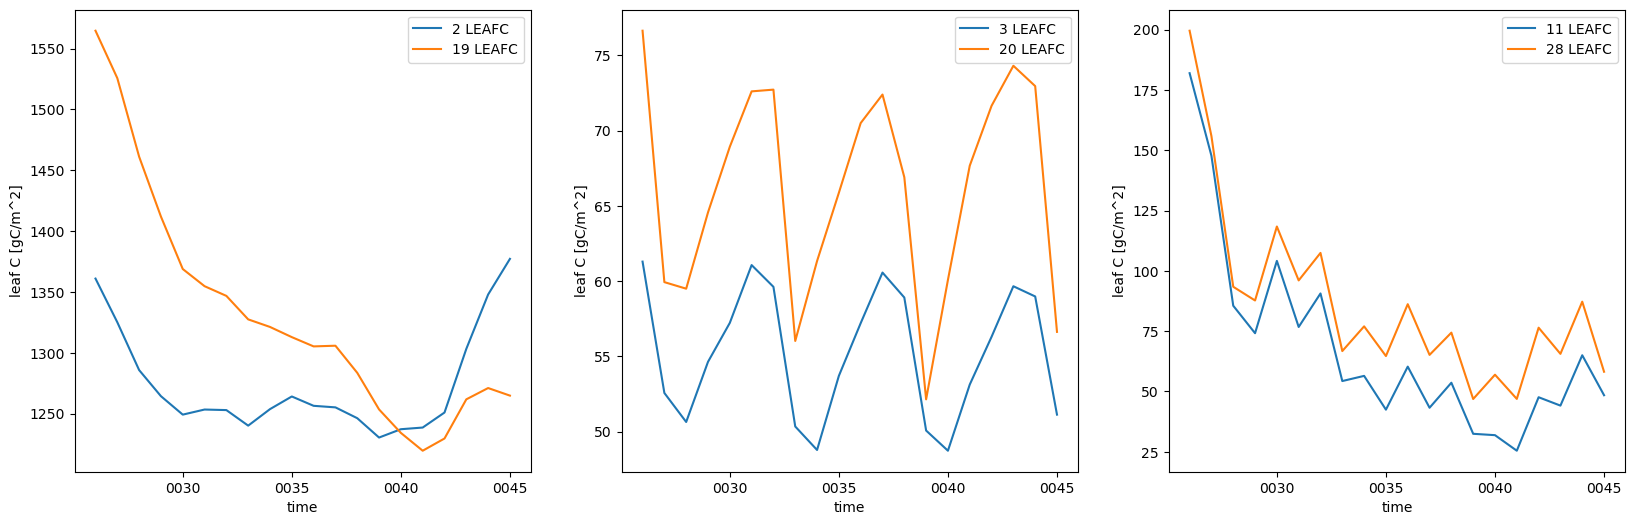

In [4]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    tlai = hr2['LEAFC'][:, pft].resample(time='1Y').mean().plot(label = str(pft) + ' LEAFC', ax = ax)
    tlai = hr2['LEAFC'][:, pft+17].resample(time='1Y').mean().plot(label = str(pft+17) + ' LEAFC', ax = ax)
    ax.legend()

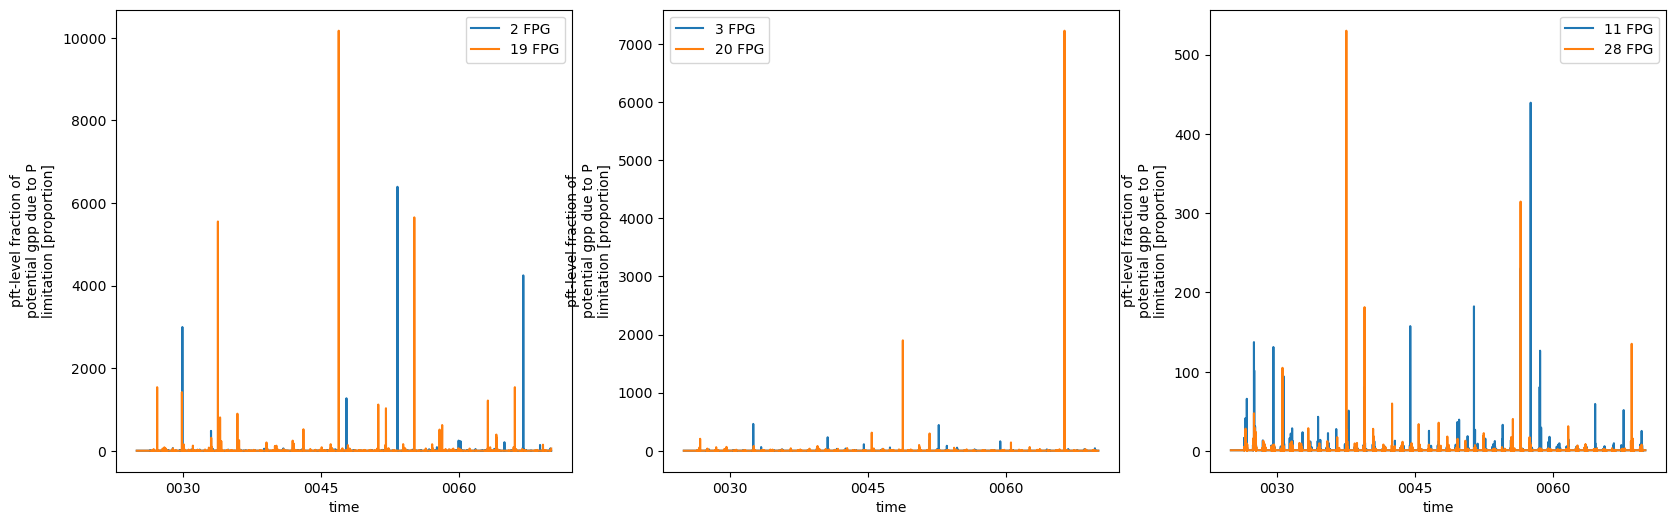

In [8]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    tlai = hr2['FPG_P_PATCH'][:, pft].plot(label = str(pft) + ' FPG', ax = ax) # resample(time='1Y').mean().
    tlai = hr2['FPG_P_PATCH'][:, pft+17].plot(label = str(pft+17) + ' FPG', ax = ax) # resample(time='1Y').mean().
    ax.legend()

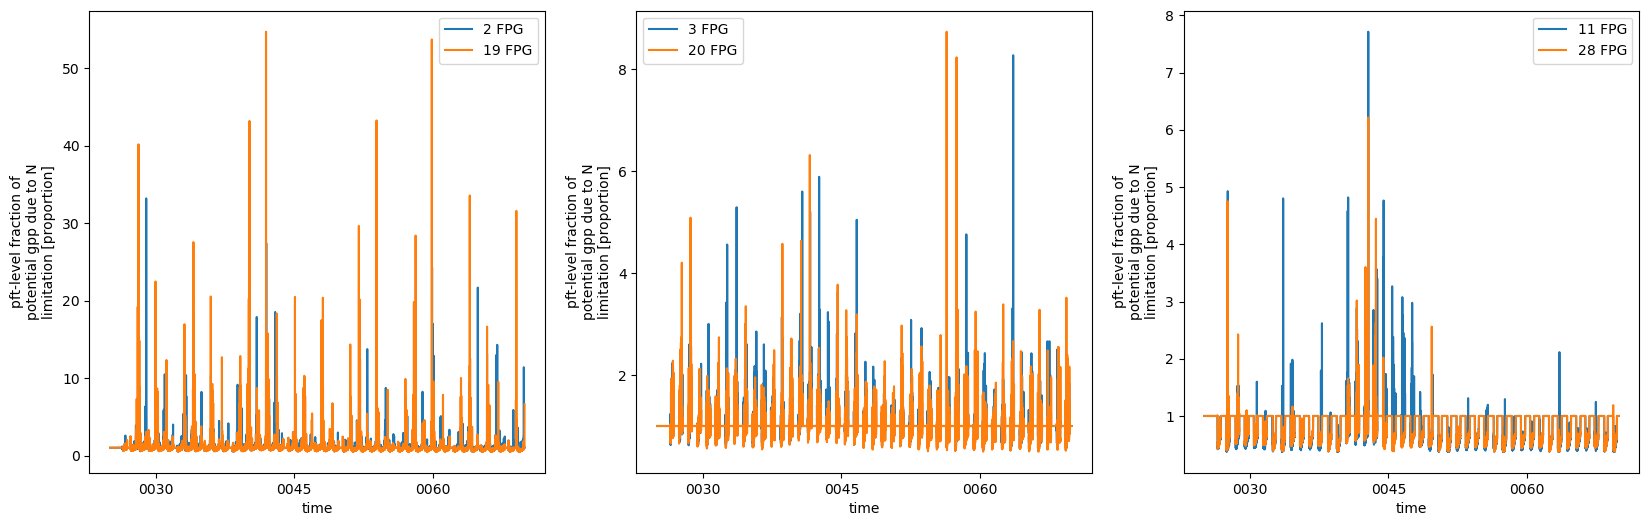

In [9]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]

    temp = np.minimum(hr2['FPG_PATCH'][:, pft], hr2['FPG_P_PATCH'][:, pft])
    tlai = temp.plot(label = str(pft) + ' FPG', ax = ax) # resample(time='1Y').mean().

    temp = np.minimum(hr2['FPG_PATCH'][:, pft+17], hr2['FPG_P_PATCH'][:, pft+17])
    tlai = temp.plot(label = str(pft+17) + ' FPG', ax = ax) # resample(time='1Y').mean().
    ax.legend()

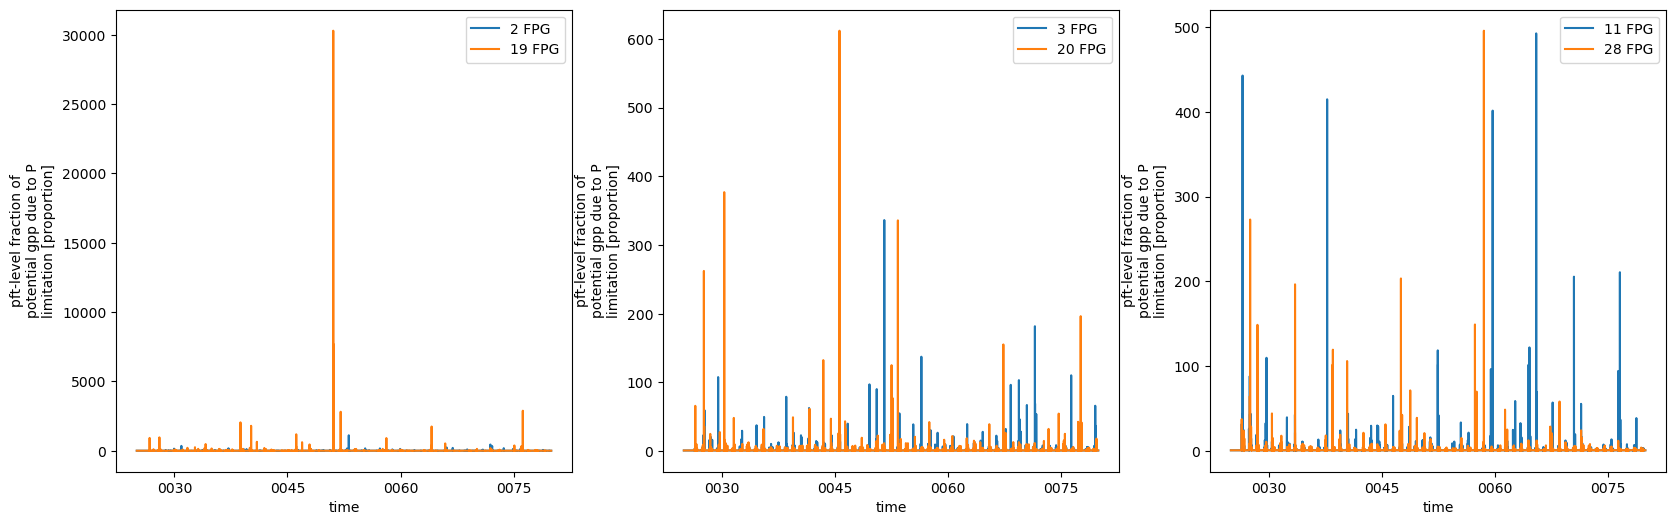

In [4]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]

    temp = hr2['FPG_P_PATCH'][:, pft]
    tlai = temp.plot(label = str(pft) + ' FPG', ax = ax) # resample(time='1Y').mean().

    temp = hr2['FPG_P_PATCH'][:, pft+17]
    tlai = temp.plot(label = str(pft+17) + ' FPG', ax = ax) # resample(time='1Y').mean().
    ax.legend()

In [11]:
hr2['FPG_PATCH'][12373:12376, 2].values, hr2['FPG_P_PATCH'][12373:12376, 2].values

(array([1.7260818, 1.       , 1.       ], dtype=float32),
 array([5.0851316, 1.       , 1.       ], dtype=float32))

In [12]:
hr2['PLANT_NABSORB'][12373:12376, 2].values, hr2['PLANT_NDEMAND'][12373:12376, 2].values, hr2['PLANT_NFUNGI_PATCH'][12373:12376, 2].values

(array([2.6475777e-07, 2.6284795e-07, 2.6246607e-07], dtype=float32),
 array([3.4987855e-09, 0.0000000e+00, 0.0000000e+00], dtype=float32),
 array([1.7493927e-09, 0.0000000e+00, 0.0000000e+00], dtype=float32))

In [13]:
hr2['PLANT_NDEMAND'][12373, 2].values == 0.

False

In [14]:
hr2['SMINN_TO_NPOOL'][12373:12376, 2].values

array([2.0324439e-08, 0.0000000e+00, 0.0000000e+00], dtype=float32)

KeyError: 'SMINN_vr'

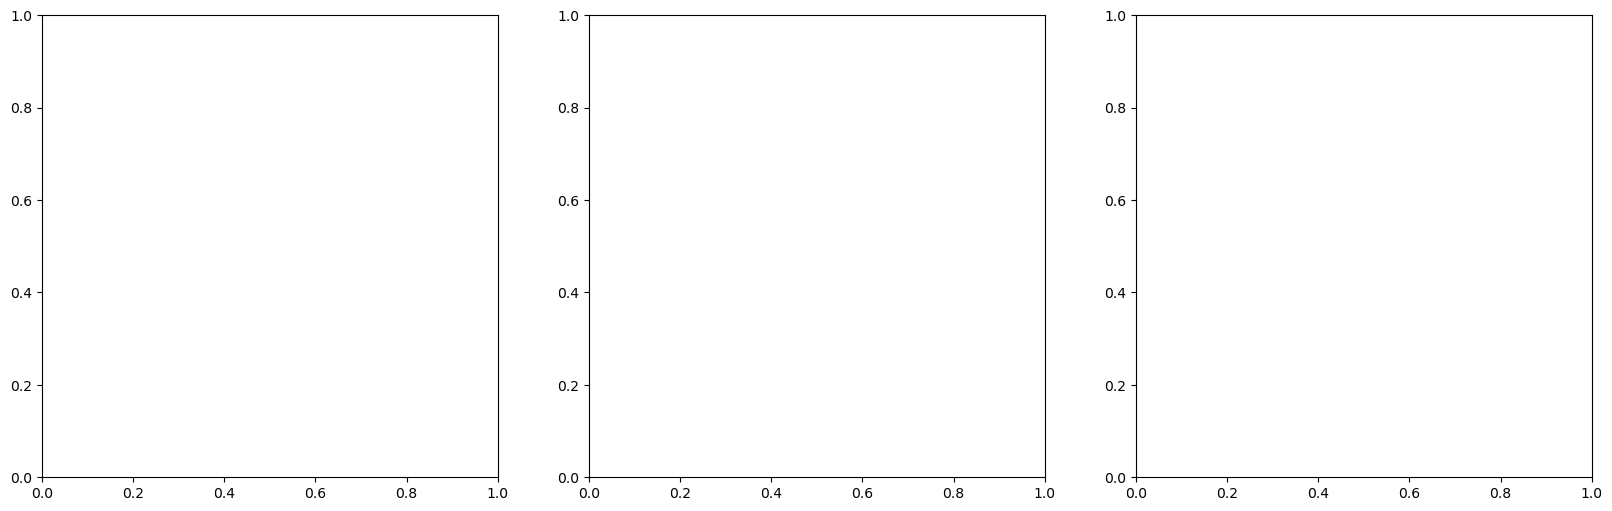

In [15]:
flist = get_colfiles_adsp('20240311_1', range(25,30))
hr = xr.open_mfdataset(flist)

fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,col in enumerate([0,1]):
    ax = axes.flat[i]
    for j in range(4):
        tlai = hr['SMINN_vr'][:, j, col].plot(ax = ax) # resample(time='1Y').mean().
    #ax.legend()

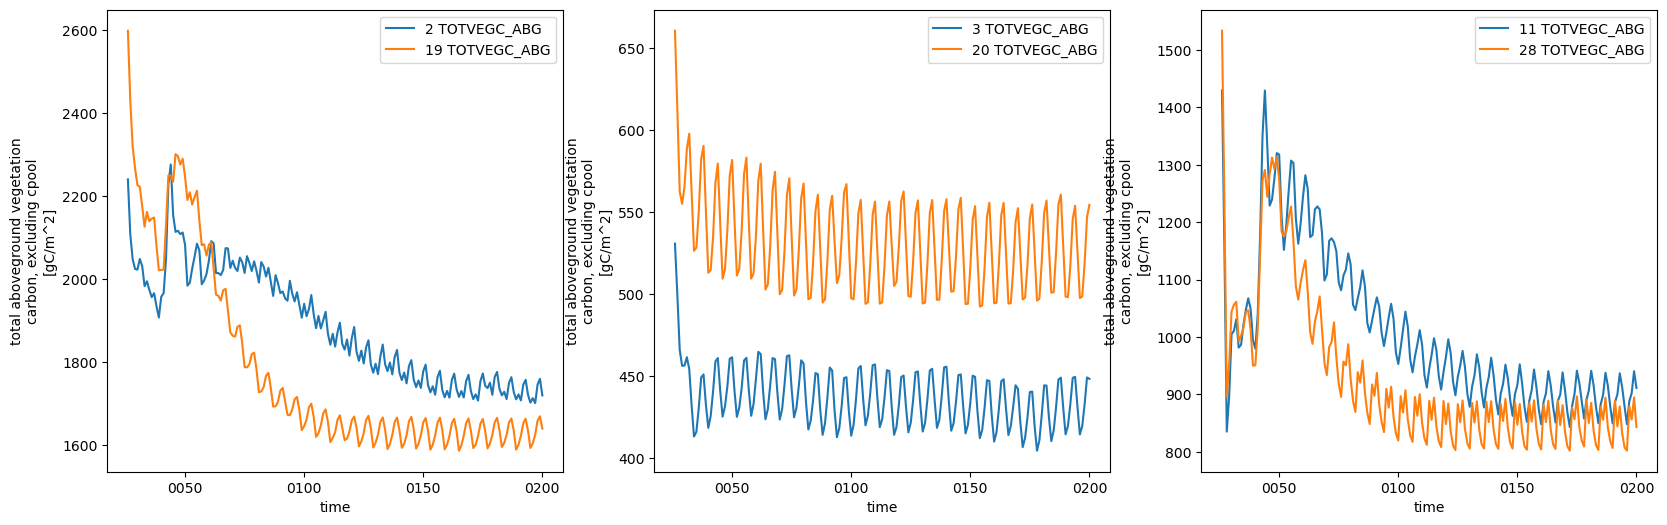

In [8]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    tlai = hr2['TOTVEGC_ABG'][:, pft].resample(time='1Y').mean().plot(label = str(pft) + ' TOTVEGC_ABG', ax = ax)
    tlai = hr2['TOTVEGC_ABG'][:, pft+17].resample(time='1Y').mean().plot(label = str(pft+17) + ' TOTVEGC_ABG', ax = ax)
    ax.legend()

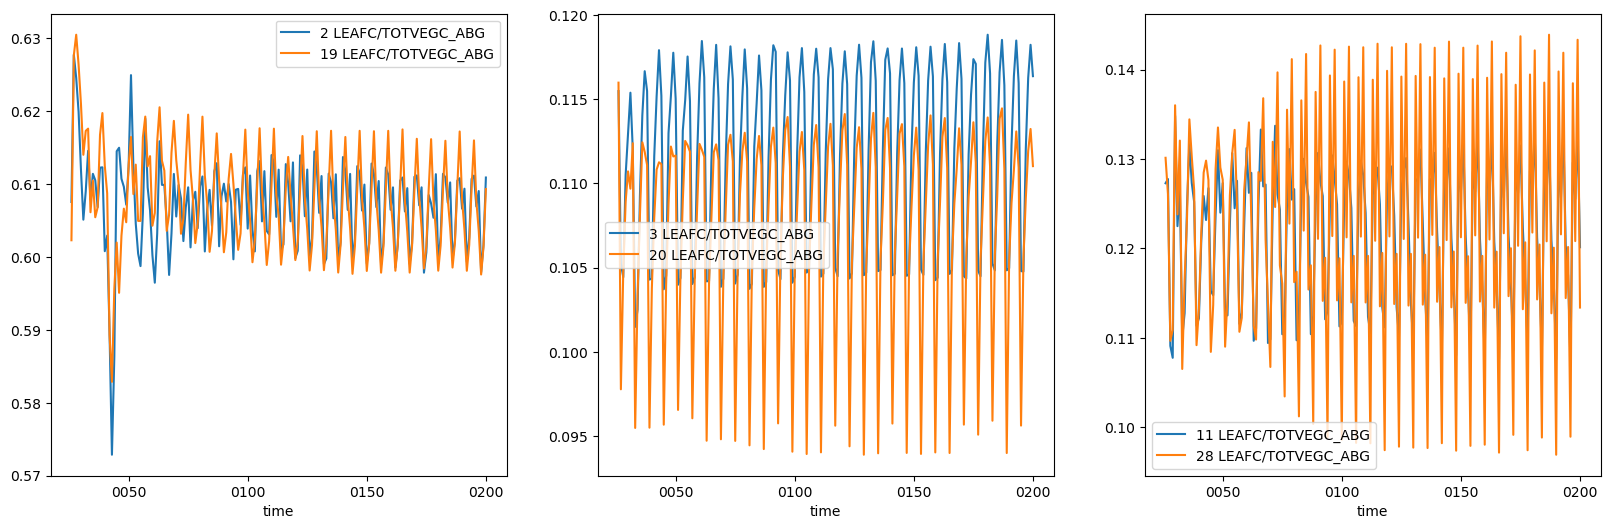

In [6]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    tlai = hr2['LEAFC'][:, pft].resample(time='1Y').mean()
    totvegc_abg = hr2['TOTVEGC_ABG'][:, pft].resample(time='1Y').mean()
    (tlai / totvegc_abg).plot(label = str(pft) + ' LEAFC/TOTVEGC_ABG', ax = ax)

    tlai = hr2['LEAFC'][:, pft+17].resample(time='1Y').mean()
    totvegc_abg = hr2['TOTVEGC_ABG'][:, pft+17].resample(time='1Y').mean()
    (tlai / totvegc_abg).plot(label = str(pft+17) + ' LEAFC/TOTVEGC_ABG', ax = ax)

    ax.legend()

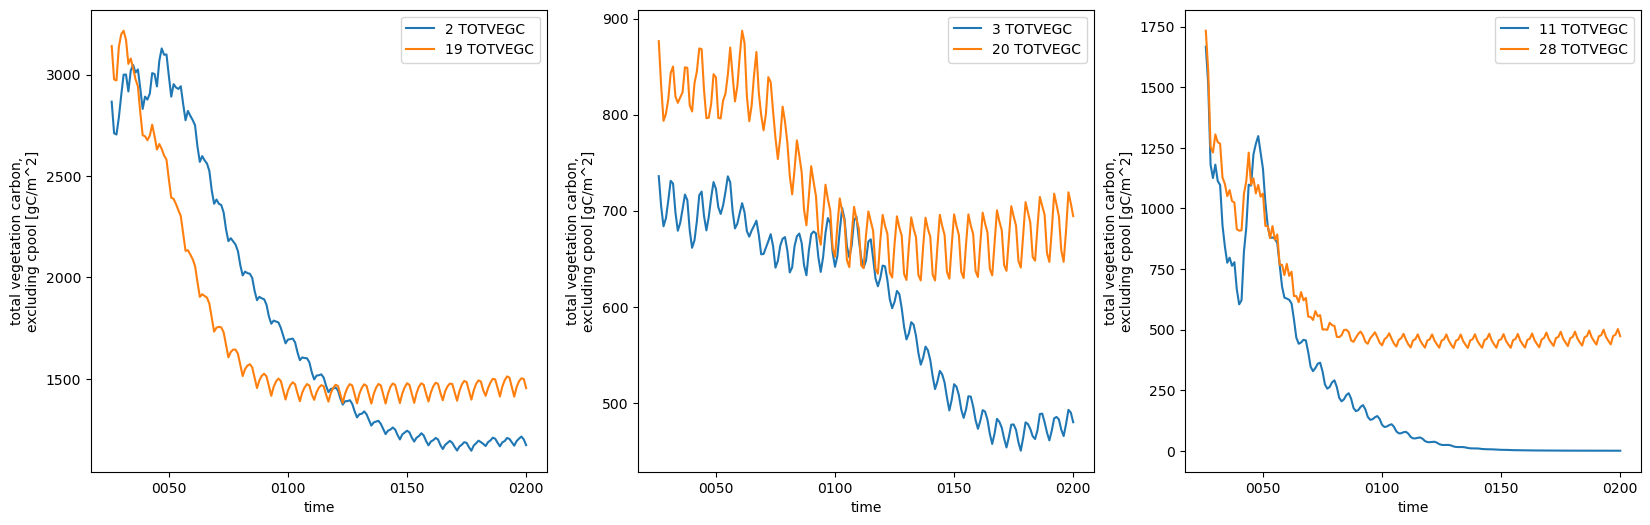

In [13]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    tlai = hr2['TOTVEGC'][:, pft].resample(time='1Y').mean().plot(label = str(pft) + ' TOTVEGC', ax = ax)
    tlai = hr2['TOTVEGC'][:, pft+17].resample(time='1Y').mean().plot(label = str(pft+17) + ' TOTVEGC', ax = ax)
    ax.legend()

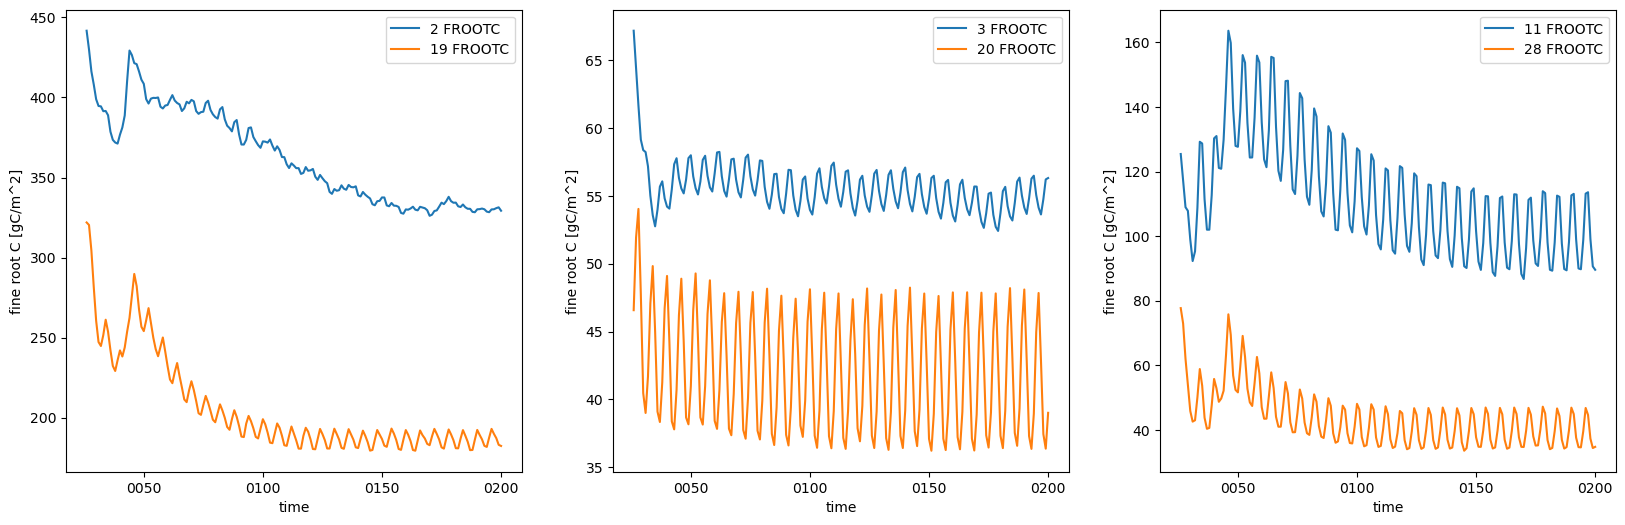

In [7]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    tlai = hr2['FROOTC'][:, pft].resample(time='1Y').mean().plot(label = str(pft) + ' FROOTC', ax = ax)
    tlai = hr2['FROOTC'][:, pft+17].resample(time='1Y').mean().plot(label = str(pft+17) + ' FROOTC', ax = ax)
    ax.legend()

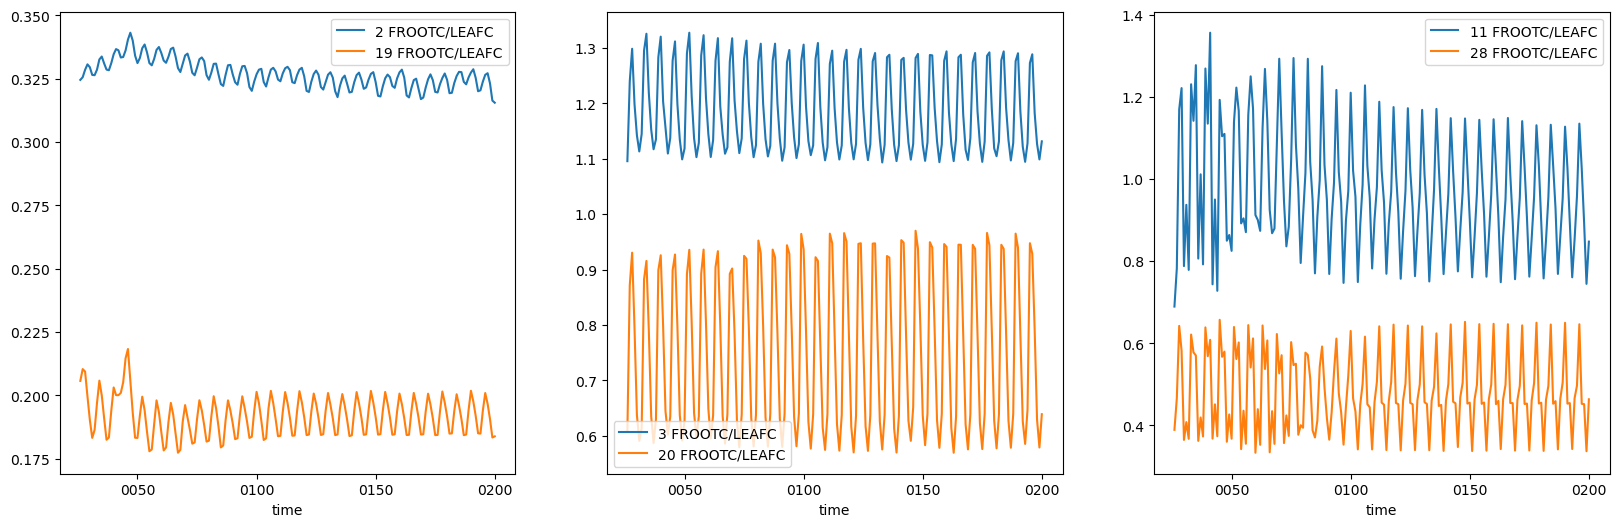

In [19]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    tlai = (hr2['FROOTC'][:,pft].resample(time='1Y').mean() / hr2['LEAFC'][:, pft].resample(time='1Y').mean()).plot(label = str(pft) + ' FROOTC/LEAFC', ax = ax)
    tlai = (hr2['FROOTC'][:, pft+17].resample(time='1Y').mean() / hr2['LEAFC'][:, pft+17].resample(time='1Y').mean()).plot(label = str(pft+17) + ' FROOTC/LEAFC', ax = ax)
    ax.legend()

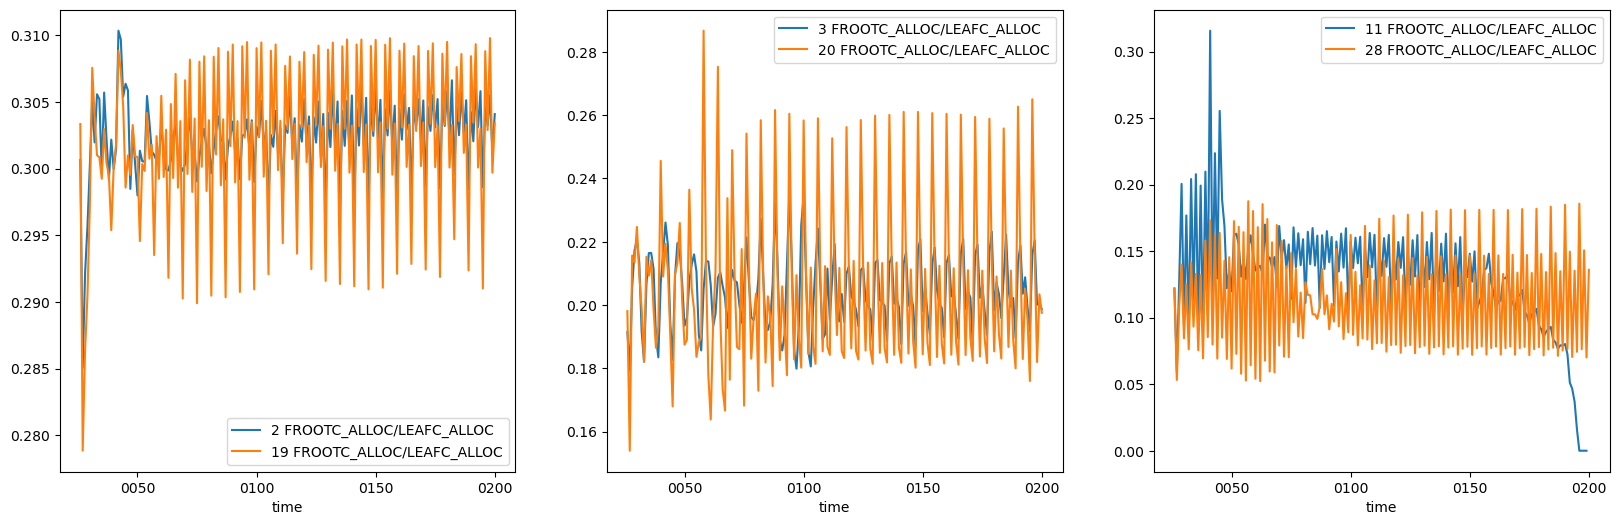

In [9]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    tlai = (hr2['FROOTC_ALLOC'][:,pft].resample(time='1Y').mean() / hr2['LEAFC_ALLOC'][:, pft].resample(time='1Y').mean()).plot(label = str(pft) + ' FROOTC_ALLOC/LEAFC_ALLOC', ax = ax)
    tlai = (hr2['FROOTC_ALLOC'][:, pft+17].resample(time='1Y').mean() / hr2['LEAFC_ALLOC'][:, pft+17].resample(time='1Y').mean()).plot(label = str(pft+17) + ' FROOTC_ALLOC/LEAFC_ALLOC', ax = ax)
    ax.legend()

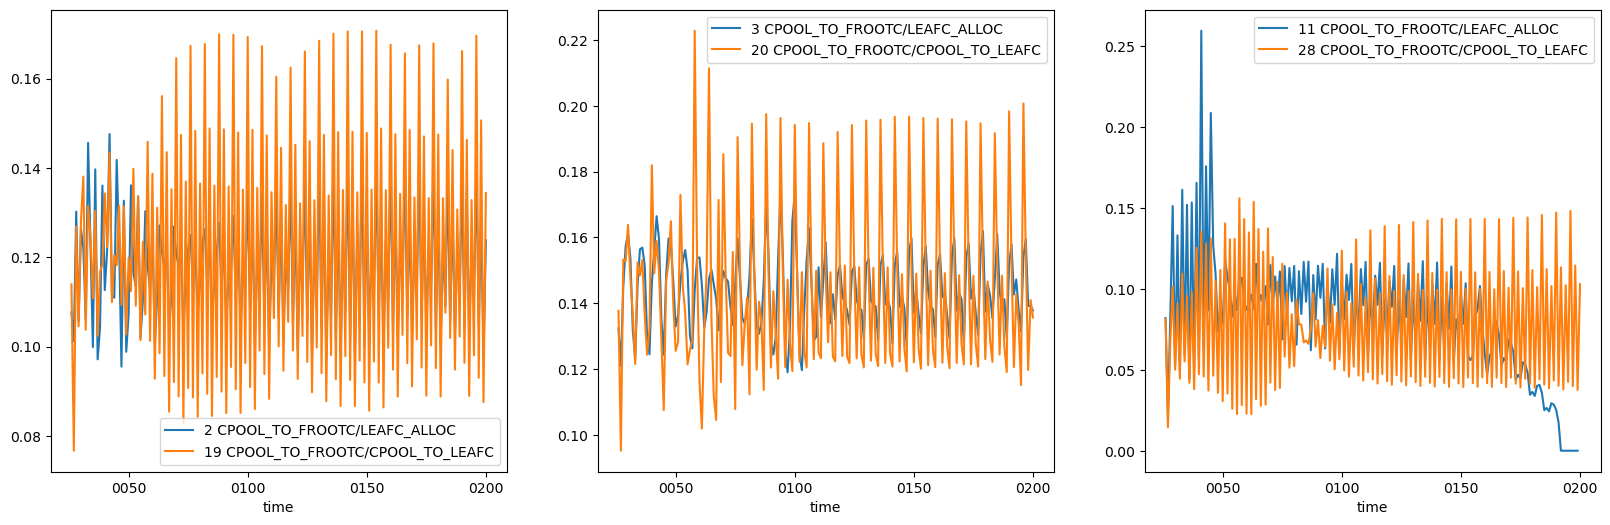

In [6]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    tlai = (hr2['CPOOL_TO_FROOTC'][:,pft].resample(time='1Y').mean() / hr2['LEAFC_ALLOC'][:, pft].resample(time='1Y').mean()).plot(label = str(pft) + ' CPOOL_TO_FROOTC/LEAFC_ALLOC', ax = ax)
    tlai = (hr2['CPOOL_TO_FROOTC'][:, pft+17].resample(time='1Y').mean() / hr2['LEAFC_ALLOC'][:, pft+17].resample(time='1Y').mean()).plot(label = str(pft+17) + ' CPOOL_TO_FROOTC/CPOOL_TO_LEAFC', ax = ax)
    ax.legend()

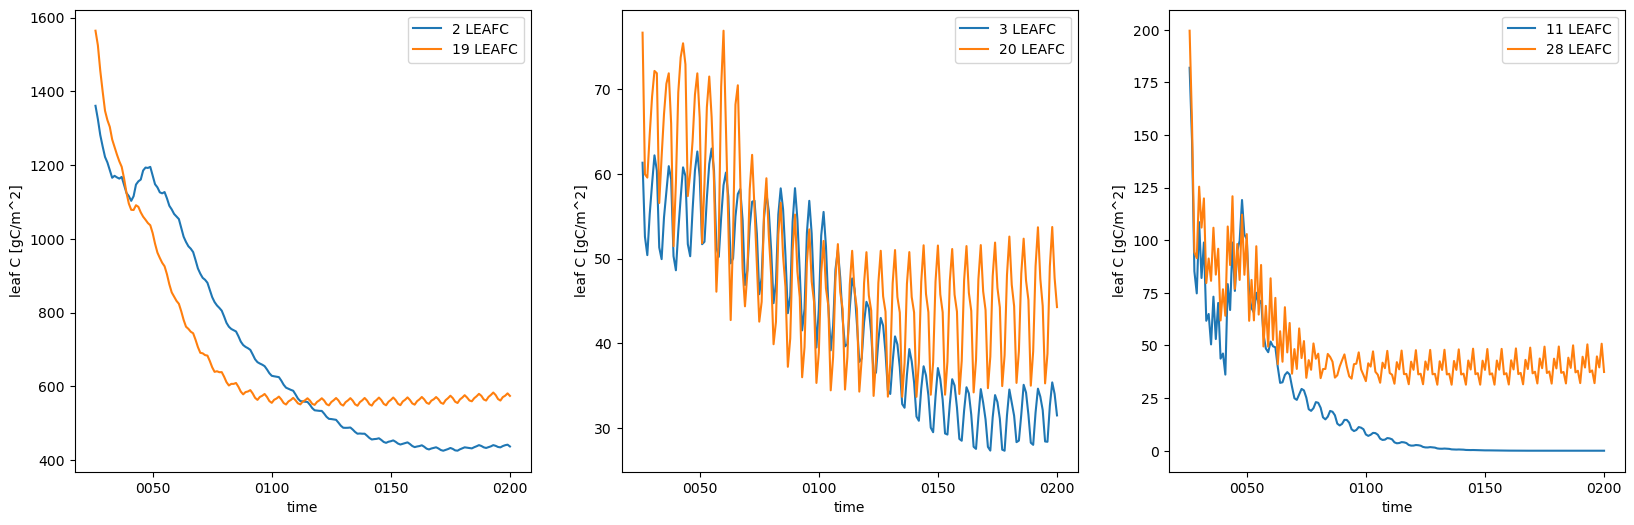

In [10]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]
    tlai = hr2['LEAFC'][:, pft].resample(time='1Y').mean().plot(label = str(pft) + ' LEAFC', ax = ax)
    tlai = hr2['LEAFC'][:, pft+17].resample(time='1Y').mean().plot(label = str(pft+17) + ' LEAFC', ax = ax)
    ax.legend()

In [11]:
flist = get_colfiles_adsp('20240316_2', range(25,200))
hr = xr.open_mfdataset(flist)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


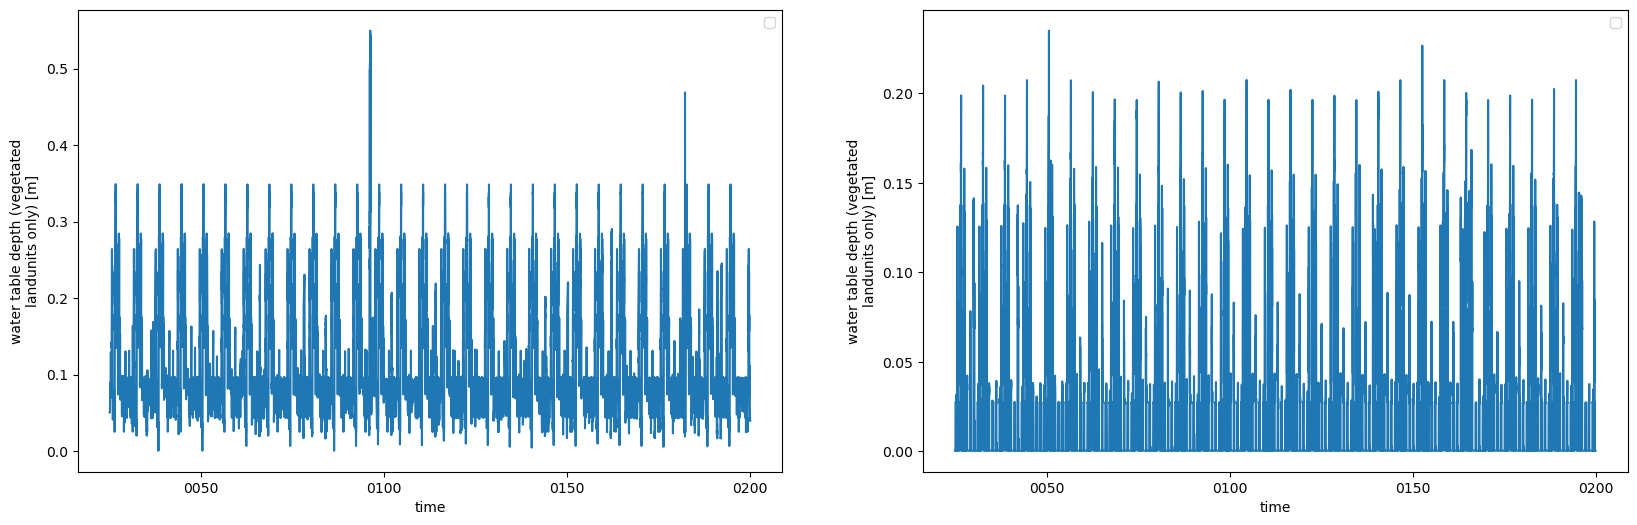

In [12]:
fig, axes = plt.subplots(1, 2, figsize = (20, 6))
for i in range(2):
    ax = axes.flat[i]
    hr['ZWT'][:, i].plot(ax = ax)
    ax.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


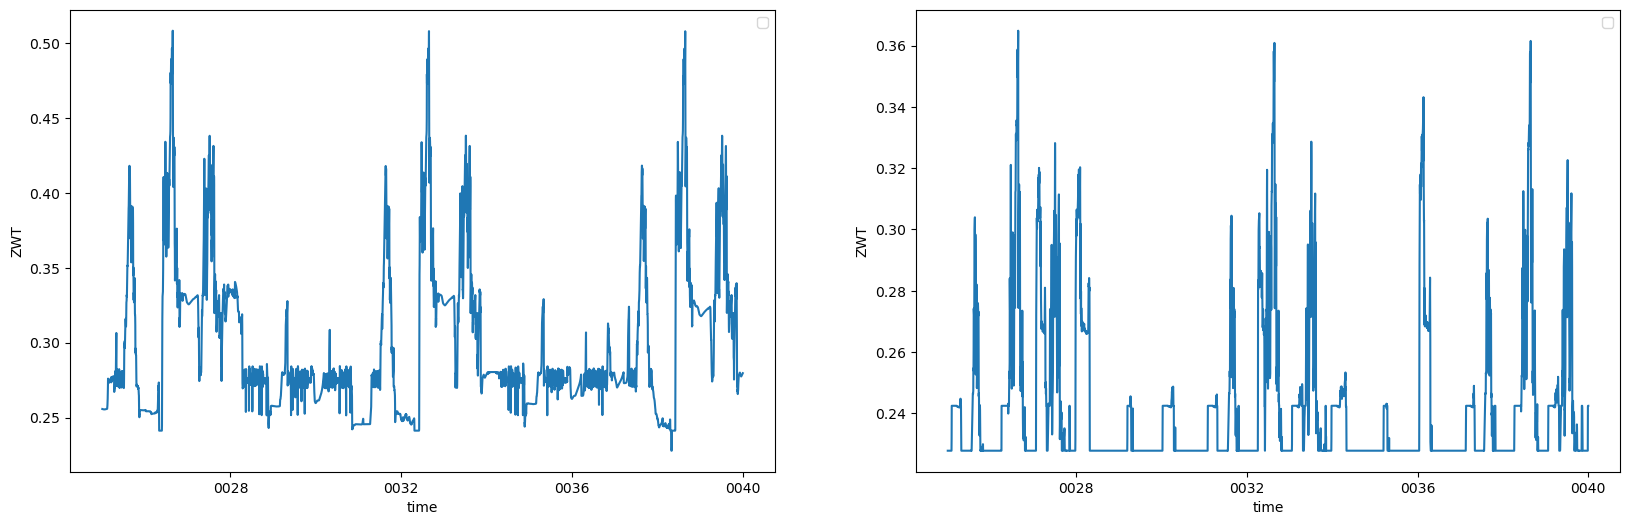

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (20, 6))
for i in range(2):
    ax = axes.flat[i]
    (10**(hr['ZWT'][:, i] - 1.33)/0.045/1.37 * 0.3).plot(ax = ax)
    ax.legend()

In [ ]:
flist = get_pftfiles_fnsp('20240311_1', range(120,146))
hr2 = xr.open_mfdataset(flist)

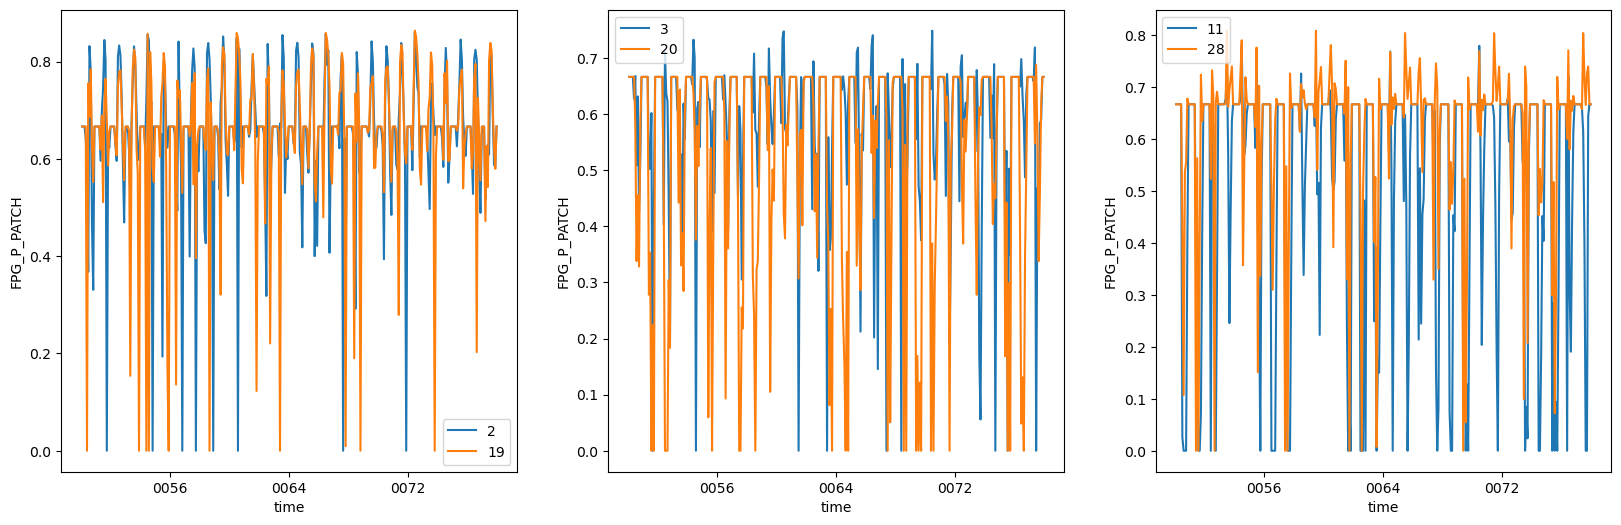

In [ ]:
fig, axes = plt.subplots(1,3,figsize = (20, 6))
for i,pft in enumerate([2,3,11]):
    ax = axes.flat[i]

    frac_fungi = hr2['FPG_P_PATCH'][:, pft].resample(time='1M').mean()
    frac_fungi = np.minimum(np.maximum(1 - (frac_fungi - 0.5) / 1.5, 0), 1)
    frac_fungi.plot(label = pft, ax = ax)

    frac_fungi = hr2['FPG_P_PATCH'][:, pft + 17].resample(time='1M').mean()
    frac_fungi = np.minimum(np.maximum(1 - (frac_fungi - 0.5) / 1.5, 0), 1)
    frac_fungi.plot(label = pft + 17, ax = ax)

    ax.legend()
    ax.set_ylabel('FPG_P_PATCH')

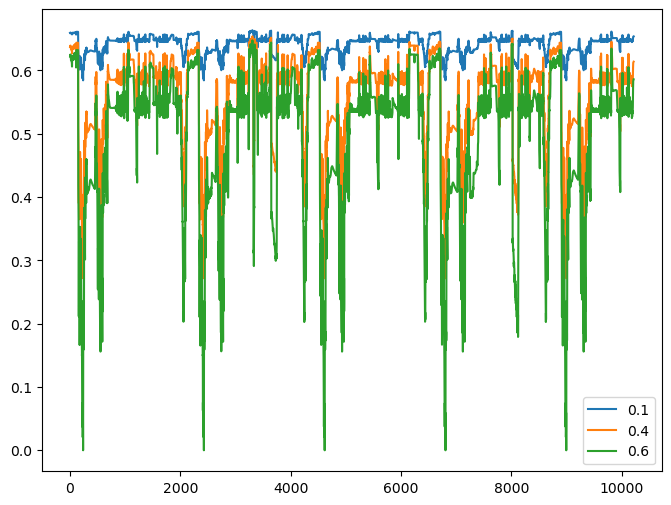

In [ ]:
zwt = hr2['ZWT'][:, 0]

plt.figure(figsize = (8, 6))
# zwt = np.linspace(-0.2, 0.4) # more positive -> deeper belowground
for slope in [0.1, 0.4, 0.6]:
    plt.plot(np.maximum(1-(np.exp(zwt/0.3 * slope) - 0.5)/1.5,0), label = slope)
    # plt.hist(np.maximum(1-(np.exp(zwt/0.3 * slope) - 0.5)/1.5,0))
plt.legend()